In [1]:
import numpy as np
import yaml
import os
import pandas as pd

directory = ''
exp_folders = os.listdir(directory)
experiment_configs = []
motor_angle_data = []
force_sensor_data = []

for subfolder in exp_folders:
    print(subfolder)
    experiment_directory = os.path.join(directory, subfolder)
    with open(os.path.join(experiment_directory,'experiment_config.yaml'), 'r') as f:
        experiment_configs.append(yaml.load(f,yaml.Loader))
    with open(os.path.join(experiment_directory, 'motor_angle.yaml'), 'r') as f:
        motor_angle_data.append(pd.DataFrame(yaml.load(f, yaml.Loader)))
    with open(os.path.join(experiment_directory,'ati_measurements.csv'),'r') as f:
        force_sensor_data.append(pd.read_csv(f))

# standardize time in the data frames
# also subtract mean force before impact and invert Fz values
for i, force_df in enumerate(force_sensor_data):
    angle_df = motor_angle_data[i]
    t0 = min(force_df['t'][0], angle_df['time_s'][0])
    force_df['t'] -= t0
    angle_df['time_s'] -= t0
    x = angle_df['motor_angle_deg'].to_numpy()
    t = angle_df['time_s'].to_numpy()
    start_idx = next(i  for i in range(x.shape[0]) if abs(x[i+1]-x[i])/(t[i+1]-t[i]) > 50)
    Fz = force_df['Fz'].to_numpy()
    zero_force = Fz[:start_idx-10].mean()
    force_df['Fz'] = (force_df['Fz']-zero_force)*-1

hardware_config.yaml


/tmp/ipykernel_533237/2234117643.py:4: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


NotADirectoryError: [Errno 20] Not a directory: '/home/joseph/workspaces/hsa_hopper/hsa_hopper_control/data/hsa_identification/2024-06-05_1717620278/hardware_config.yaml/experiment_config.yaml'

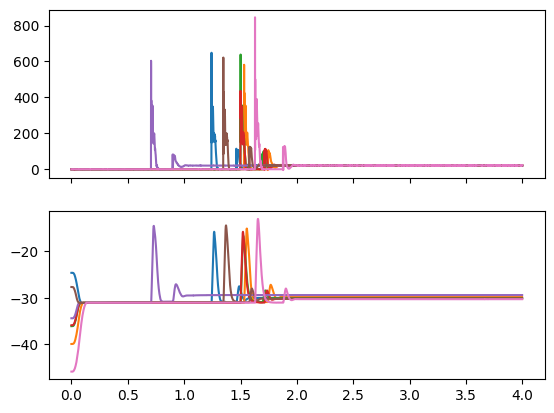

In [68]:
from matplotlib import pyplot as plt 

def plot_z_force(ax, df):
    ax.plot(df['t'], df['Fz'])

def plot_motor_angle(ax, df):
    ax.plot(df['time_s'], df['motor_angle_deg'])

fig, ax = plt.subplots(nrows=2, ncols=1, sharex=True)
for i, force_df in enumerate(force_sensor_data):
    angle_df = motor_angle_data[i]
    plot_z_force(ax[0], force_df)
    plot_motor_angle(ax[1], angle_df)

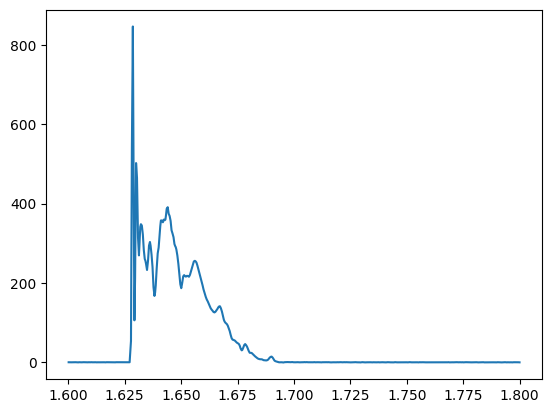

In [74]:
df = force_sensor_data[-1]
sub_df = df[df['t'] < 1.8]
sub_df = sub_df[sub_df['t'] > 1.6]
plt.plot(sub_df['t'], sub_df['Fz'])
# plt.plot(motor_angle_data[-1]['time_s'], motor_angle_data[-1]['motor_angle_deg'])
# print(experiment_configs[0])